# 🛒 DQFresh Mart Retail — Hackathon Solution
### `HACK-2026-PYTHON-01` | DQLab × UjiKompetensi

**Objective:** Replicate Sophia's analysis to uncover *Rising Star* products with consistent growth that were hidden in traditional top-10 dashboards, and identify frequent product-pair bundles using the Apriori algorithm.

**Outputs produced:**
| File | Description |
|---|---|
| `retail_insight.xlsx` | Excel with *Rising Star* & *Potential Packaging* sheets |
| `rising_star_index.png` | Relative (indexed) growth chart |
| `rising_star_actual.png` | Actual MA sales value chart |

---
## 0 · Environment Setup

In [ ]:
# Install / verify required libraries
# Uncomment if running for the first time
!pip install pandas==2.3.1 matplotlib==3.10.7 mlxtend==0.23.4 openpyxl==3.1.5

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


---
## 1 · Load & Inspect Dataset

In [ ]:
# ── Load raw sales data ──────────────────────────────────────────────────────
df = pd.read_excel('data_penjualan.xlsx')

# Parse date column
df['tgl_transaksi'] = pd.to_datetime(df['tgl_transaksi'])

print(f'Shape : {df.shape}')
print(f'Period: {df["tgl_transaksi"].min().date()} → {df["tgl_transaksi"].max().date()}')
print(f'Unique products : {df["kode_produk"].nunique()}')
print(f'Unique receipts : {df["nomor_struk"].nunique()}')
df.head()

Shape : (42446, 7)
Period: 2025-02-01 → 2025-03-04
Unique products : 58
Unique receipts : 9403


,nomor_struk,tgl_transaksi,kode_produk,nama_produk,jumlah_terjual,harga,total_nilai
0,INV-00000001,2025-02-01,MARGRN,Margarin Serbaguna,4,18000,72000
1,INV-00000002,2025-02-01,DISF1L,Cairan Disinfektan 1L,5,60500,302500
2,INV-00000002,2025-02-01,AMGALN,Air Mineral Galon,1,15500,15500
3,INV-00000002,2025-02-01,SNKKPT,Snack Keripik Kentang,1,20500,20500
4,INV-00000002,2025-02-01,BANTAL,Bantal Tidur Silikon,2,66500,133000


In [ ]:
# Quick data quality check (no cleansing required per spec)
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Data types:')
print(df.dtypes)

Missing values per column:
nomor_struk       0
tgl_transaksi     0
kode_produk       0
nama_produk       0
jumlah_terjual    0
harga             0
total_nilai       0
dtype: int64

Data types:
nomor_struk               object
tgl_transaksi     datetime64[ns]
kode_produk               object
nama_produk               object
jumlah_terjual             int64
harga                      int64
total_nilai                int64
dtype: object


---
## 2 · Rising Star Analysis

Steps:
1. Aggregate `total_nilai` per product per day
2. Compute 3-day Moving Average (MA)
3. Detect the longest *Rising Trend Session* (consecutive days MA↑)
4. Filter products with ≥ 12 consecutive uptrend days
5. Compute Growth % using **end-point vs start-point** of that session

In [ ]:
# ── Step 1: Daily sales per product ─────────────────────────────────────────
daily = (
    df.groupby(['kode_produk', 'nama_produk', 'tgl_transaksi'])['total_nilai']
    .sum()
    .reset_index()
    .sort_values(['kode_produk', 'tgl_transaksi'])
)

# Build a complete date range so every product has a row for every day
all_dates = pd.date_range(df['tgl_transaksi'].min(), df['tgl_transaksi'].max(), freq='D')
products = df[['kode_produk', 'nama_produk']].drop_duplicates()

# Cross-join products × dates, then merge actual sales
full_index = products.assign(key=1).merge(
    pd.DataFrame({'tgl_transaksi': all_dates, 'key': 1}), on='key'
).drop(columns='key')

daily_full = full_index.merge(daily, on=['kode_produk', 'nama_produk', 'tgl_transaksi'], how='left')
daily_full['total_nilai'] = daily_full['total_nilai'].fillna(0)

print(f'Daily full shape: {daily_full.shape}')
daily_full.head(10)

Daily full shape: (1856, 4)


,kode_produk,nama_produk,tgl_transaksi,total_nilai
0,MARGRN,Margarin Serbaguna,2025-02-01,3222000.0
1,MARGRN,Margarin Serbaguna,2025-02-02,1278000.0
2,MARGRN,Margarin Serbaguna,2025-02-03,1566000.0
3,MARGRN,Margarin Serbaguna,2025-02-04,3186000.0
4,MARGRN,Margarin Serbaguna,2025-02-05,2484000.0
5,MARGRN,Margarin Serbaguna,2025-02-06,810000.0
6,MARGRN,Margarin Serbaguna,2025-02-07,0.0
7,MARGRN,Margarin Serbaguna,2025-02-08,972000.0
8,MARGRN,Margarin Serbaguna,2025-02-09,1944000.0
9,MARGRN,Margarin Serbaguna,2025-02-10,2736000.0


In [ ]:
# ── Step 2: 3-day Moving Average ─────────────────────────────────────────────
daily_full = daily_full.sort_values(['kode_produk', 'tgl_transaksi'])

daily_full['ma3'] = (
    daily_full
    .groupby('kode_produk')['total_nilai']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

daily_full[['kode_produk', 'nama_produk', 'tgl_transaksi', 'total_nilai', 'ma3']].head(10)

,kode_produk,nama_produk,tgl_transaksi,total_nilai,ma3
1600,ALMAKS,Set Alat Makan Stainless,2025-02-01,451500.0,451500.0
1601,ALMAKS,Set Alat Makan Stainless,2025-02-02,451500.0,451500.0
1602,ALMAKS,Set Alat Makan Stainless,2025-02-03,580500.0,494500.0
1603,ALMAKS,Set Alat Makan Stainless,2025-02-04,451500.0,494500.0
1604,ALMAKS,Set Alat Makan Stainless,2025-02-05,258000.0,430000.0
1605,ALMAKS,Set Alat Makan Stainless,2025-02-06,387000.0,365500.0
1606,ALMAKS,Set Alat Makan Stainless,2025-02-07,322500.0,322500.0
1607,ALMAKS,Set Alat Makan Stainless,2025-02-08,774000.0,494500.0
1608,ALMAKS,Set Alat Makan Stainless,2025-02-09,838500.0,645000.0
1609,ALMAKS,Set Alat Makan Stainless,2025-02-10,645000.0,752500.0


In [ ]:
# ── Step 3 & 4: Longest consecutive uptrend session ─────────────────────────

def analyze_trend(group: pd.DataFrame) -> dict:
    """Return the longest rising trend session details for a product group."""
    ma = group['ma3'].values
    dates = group['tgl_transaksi'].values

    max_len = 0
    best_start_idx = 0
    best_end_idx = 0

    cur_len = 0
    cur_start_idx = 0

    for i in range(1, len(ma)):
        if ma[i] > ma[i - 1]:          # uptrend day
            if cur_len == 0:
                cur_start_idx = i - 1   # session starts at previous day
            cur_len += 1
            if cur_len > max_len:
                max_len = cur_len
                best_start_idx = cur_start_idx
                best_end_idx = i
        else:
            cur_len = 0                 # reset on non-uptrend day

    # Consecutive days = number of days in session (inclusive)
    # e.g. 12 uptrend transitions = 13 days span; count = max_len consecutive rises
    return {
        'max_streak': max_len,          # number of consecutive rising MA days
        'start_idx': best_start_idx,
        'end_idx': best_end_idx,
        'ma_start': ma[best_start_idx] if max_len > 0 else None,
        'ma_end': ma[best_end_idx] if max_len > 0 else None,
        'date_start': dates[best_start_idx] if max_len > 0 else None,
        'date_end': dates[best_end_idx] if max_len > 0 else None,
    }

trend_results = []
for (kode, nama), grp in daily_full.sort_values('tgl_transaksi').groupby(['kode_produk', 'nama_produk']):
    res = analyze_trend(grp.reset_index(drop=True))
    res['kode_produk'] = kode
    res['nama_produk'] = nama
    trend_results.append(res)

trend_df = pd.DataFrame(trend_results)
print(f'Products analysed: {len(trend_df)}')
trend_df[['kode_produk', 'nama_produk', 'max_streak', 'ma_start', 'ma_end']].sort_values('max_streak', ascending=False).head(10)

Products analysed: 58


,kode_produk,nama_produk,max_streak,ma_start,ma_end
57,WJANEM,Wajan Enamel Anti Lengket,23,0.000000e+00,2.800000e+06
40,SCC15L,Sabun Cuci Cair 1.5L,20,0.000000e+00,6.008333e+06
4,BRS5KG,Beras Premium 5kg,12,0.000000e+00,3.432000e+06
27,MGR1L,Minyak Goreng Refill 1L,10,0.000000e+00,2.747500e+06
9,DEOSPR,Deodoran Spray,8,4.290000e+05,3.135000e+06
51,TISWJH,Tisu Wajah Pack Ganda,7,2.166667e+05,2.600000e+06
47,STRIKA,Setrika Listrik Standar,6,9.950000e+05,2.089500e+06
3,BATAA4,Baterai AA (Isi 4),5,9.145000e+05,2.345667e+06
39,SACTAN,Sabun Cuci Tangan Reffil,5,1.225000e+06,2.795000e+06
34,PSGIGI,Pasta Gigi Pack Besar,5,5.326667e+05,1.214167e+06


In [ ]:
# ── Step 4: Filter ≥ 12 consecutive uptrend days ─────────────────────────────
THRESHOLD = 12
rising_raw = trend_df[trend_df['max_streak'] >= THRESHOLD].copy()
print(f'Rising Star candidates: {len(rising_raw)}')
rising_raw[['kode_produk', 'nama_produk', 'max_streak']]

Rising Star candidates: 3


,kode_produk,nama_produk,max_streak
4,BRS5KG,Beras Premium 5kg,12
40,SCC15L,Sabun Cuci Cair 1.5L,20
57,WJANEM,Wajan Enamel Anti Lengket,23


In [ ]:
# ── Step 5: Growth % (End-Point vs Start-Point) ──────────────────────────────
rising_raw['growth_pct'] = (
    (rising_raw['ma_end'] / rising_raw['ma_start'] - 1) * 100
).round(2)

# Total Penjualan = sum of all actual daily sales for the product
total_sales = (
    df.groupby('kode_produk')['total_nilai'].sum()
    .reset_index()
    .rename(columns={'total_nilai': 'total_penjualan'})
)
rising_raw = rising_raw.merge(total_sales, on='kode_produk')

# Build final Rising Star table
rising_star = (
    rising_raw[['kode_produk', 'nama_produk', 'growth_pct', 'total_penjualan']]
    .rename(columns={
        'kode_produk'  : 'Kode Produk',
        'nama_produk'  : 'Nama Produk',
        'growth_pct'   : 'Growth %',
        'total_penjualan': 'Total Penjualan',
    })
    .sort_values('Growth %', ascending=False)
    .reset_index(drop=True)
)

rising_star

,Kode Produk,Nama Produk,Growth %,Total Penjualan
0,BRS5KG,Beras Premium 5kg,inf,44109000
1,SCC15L,Sabun Cuci Cair 1.5L,inf,95970000
2,WJANEM,Wajan Enamel Anti Lengket,inf,44240000


---
## 3 · Potential Packaging — Apriori

In [ ]:
# ── Build basket (one-hot encoded transactions) ──────────────────────────────
basket = (
    df.groupby(['nomor_struk', 'nama_produk'])['jumlah_terjual']
    .sum()
    .unstack(fill_value=0)
    .reset_index(drop=True)
)

# Binarize: any qty > 0 → True
basket_bin = basket.applymap(lambda x: True if x > 0 else False)

print(f'Basket shape (invoices × products): {basket_bin.shape}')
basket_bin.head(3)

Basket shape (invoices × products): (9403, 58)


nama_produk,Air Mineral Galon,Bantal Tidur Silikon,Baterai AA (Isi 4),Beras Premium 5kg,Botol Minum Plastik,Cairan Disinfektan 1L,Cairan Pembersih Lantai 2L,Celana Pendek Santai,Deodoran Spray,Deterjen Bubuk 800g,...,Susu Formula Anak (Box),Tas Belanja Reusable,Teko Listrik,Telur Ayam (Setengah Kg),Tepung Terigu 1kg,Termos Air Panas 500ml,Tisu Wajah Pack Ganda,Vitamin C (Botol Isi 30),Wadah Penyimpanan Makanan,Wajan Enamel Anti Lengket
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,True,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# ── Run Apriori ──────────────────────────────────────────────────────────────
frequent_itemsets = apriori(
    basket_bin,
    min_support=0.01,
    use_colnames=True,
    verbose=0
)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')
frequent_itemsets.head()

Frequent itemsets found: 748


,support,itemsets
0,0.252579,(Air Mineral Galon)
1,0.017441,(Bantal Tidur Silikon)
2,0.089865,(Baterai AA (Isi 4))
3,0.041582,(Beras Premium 5kg)
4,0.013719,(Botol Minum Plastik)


In [ ]:
# ── Generate association rules (lift metric) ─────────────────────────────────
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)
print(f'Total rules before filtering: {len(rules)}')
rules.head(3)

Total rules before filtering: 3070


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Air Mineral Galon),(Baterai AA (Isi 4)),0.252579,0.089865,0.033181,0.131368,1.461843,1.0,0.010483,1.047780,0.422696,0.107290,0.045601,0.250300
1,(Baterai AA (Isi 4)),(Air Mineral Galon),0.089865,0.252579,0.033181,0.369231,1.461843,1.0,0.010483,1.184936,0.347126,0.107290,0.156072,0.250300
2,(Beras Premium 5kg),(Air Mineral Galon),0.041582,0.252579,0.013081,0.314578,1.245464,1.0,0.002578,1.090454,0.205637,0.046538,0.082951,0.183184


In [ ]:
# ── Filter: at least one Rising Star product in rule + lift ≥ 2 ──────────────
rising_star_names = set(rising_star['Nama Produk'].tolist())
total_invoices = df['nomor_struk'].nunique()

def has_rising_star(antecedents, consequents):
    combined = set(antecedents) | set(consequents)
    return bool(combined & rising_star_names)

mask_rs  = rules.apply(lambda r: has_rising_star(r['antecedents'], r['consequents']), axis=1)
mask_lift = rules['lift'] >= 2

filtered = rules[mask_rs & mask_lift].copy()
print(f'Rules after filtering: {len(filtered)}')

# Format output columns
filtered['Jika Membeli'] = filtered['antecedents'].apply(lambda x: ', '.join(sorted(x)))
filtered['Maka Membeli'] = filtered['consequents'].apply(lambda x: ', '.join(sorted(x)))
filtered['Jumlah Invoice'] = (filtered['support'] * total_invoices).round(0).astype(int)
filtered['Support']    = filtered['support'].round(4)
filtered['Confidence'] = filtered['confidence'].round(4)
filtered['Lift']       = filtered['lift'].round(4)

potential_packaging = (
    filtered[['Jika Membeli', 'Maka Membeli', 'Jumlah Invoice', 'Support', 'Confidence', 'Lift']]
    .sort_values(['Lift', 'Support', 'Confidence'], ascending=False)
    .reset_index(drop=True)
)

potential_packaging.head(10)

Rules after filtering: 10


,Jika Membeli,Maka Membeli,Jumlah Invoice,Support,Confidence,Lift
0,Beras Premium 5kg,Minyak Goreng Refill 1L,100,0.0106,0.2558,2.3013
1,Minyak Goreng Refill 1L,Beras Premium 5kg,100,0.0106,0.0957,2.3013
2,"Kaos Kaki (3 Pasang), Sabun Cuci Cair 1.5L",Minyak Goreng Refill 1L,185,0.0197,0.2510,2.2587
3,Minyak Goreng Refill 1L,"Kaos Kaki (3 Pasang), Sabun Cuci Cair 1.5L",185,0.0197,0.1770,2.2587
4,"Kaos Kaki (3 Pasang), Minyak Goreng Refill 1L",Sabun Cuci Cair 1.5L,185,0.0197,0.2144,2.2273
5,Sabun Cuci Cair 1.5L,"Kaos Kaki (3 Pasang), Minyak Goreng Refill 1L",185,0.0197,0.2044,2.2273
6,"Cairan Pembersih Lantai 2L, Kaos Kaki (3 Pasang)",Sabun Cuci Cair 1.5L,103,0.0110,0.2032,2.1108
7,Sabun Cuci Cair 1.5L,"Cairan Pembersih Lantai 2L, Kaos Kaki (3 Pasang)",103,0.0110,0.1138,2.1108
8,Sabun Cuci Cair 1.5L,Minyak Goreng Refill 1L,208,0.0221,0.2298,2.0681
9,Minyak Goreng Refill 1L,Sabun Cuci Cair 1.5L,208,0.0221,0.1990,2.0681


---
## 4 · Export to Excel — `retail_insight.xlsx`

In [ ]:
EXCEL_PATH = 'retail_insight.xlsx'

with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:
    # Sheet 1 — Rising Star
    rising_star.to_excel(writer, sheet_name='Rising Star', index=False)

    # Sheet 2 — Potential Packaging
    potential_packaging.to_excel(writer, sheet_name='Potential Packaging', index=False)

    # ── Auto-fit column widths (nice to have) ────────────────────────────────
    for sheet_name in writer.sheets:
        ws = writer.sheets[sheet_name]
        for col in ws.columns:
            max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

print(f'✅ Saved: {EXCEL_PATH}')

✅ Saved: retail_insight.xlsx


---
## 5 · Visualizations

### 5a. Chart 1 — Relative Growth Index (`rising_star_index.png`)

In [ ]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def get_ma_pivot(products_kode: list) -> pd.DataFrame:
    """Return a date-indexed pivot of 3-day MA for given product codes."""
    subset = daily_full[daily_full['kode_produk'].isin(products_kode)].copy()
    pivot = subset.pivot(index='tgl_transaksi', columns='nama_produk', values='ma3')
    return pivot

# Top-3 products by total sales overall
top3_products = (
    total_sales
    .sort_values('total_penjualan', ascending=False)
    .head(3)
)
top3_kode  = top3_products['kode_produk'].tolist()

# Rising star product codes (already ranked by Growth %)
rising_kode = rising_raw.sort_values('growth_pct', ascending=False)['kode_produk'].tolist()

# Combine and fetch MA pivot
all_kode = list(dict.fromkeys(rising_kode + top3_kode))   # deduplicate, preserve order
pivot_all = get_ma_pivot(all_kode)

print('Rising Stars :', rising_kode)
print('Top-3        :', top3_kode)

Rising Stars : ['BRS5KG', 'SCC15L', 'WJANEM']
Top-3        : ['KSKK3P', 'TEKOLT', 'KBLCHG']


In [ ]:
# ── Normalize to Base-100 ─────────────────────────────────────────────────────
def normalize_base100(df: pd.DataFrame) -> pd.DataFrame:
    first_valid = df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else 1)
    return (df / first_valid * 100)

pivot_indexed = normalize_base100(pivot_all)
pivot_indexed.head(5)

nama_produk,Beras Premium 5kg,Kabel Data Fast Charge,Kaos Kaki (3 Pasang),Sabun Cuci Cair 1.5L,Teko Listrik,Wajan Enamel Anti Lengket
tgl_transaksi,,,,,,
2025-02-01,100.000000,100.000000,100.000000,100.000000,100.000000,NaN
2025-02-02,150.000000,94.871795,102.156863,120.000000,111.274510,inf
2025-02-03,166.666667,96.581197,99.934641,137.777778,113.725490,inf
2025-02-04,244.444444,94.188034,93.790850,175.555556,118.300654,inf
2025-02-05,311.111111,93.846154,92.810458,222.222222,113.071895,inf


In [ ]:
# ── Rising-star name lookup (kode → nama) ─────────────────────────────────────
kode_to_nama = dict(zip(
    daily_full['kode_produk'], daily_full['nama_produk']
))
top3_nama   = [kode_to_nama[k] for k in top3_kode]
rising_nama = [kode_to_nama[k] for k in rising_kode]

# Color palettes
RISING_COLORS = [
    '#E84855', '#3A86FF', '#06D6A0', '#FFB703',
    '#8338EC', '#FB5607', '#219EBC', '#70E000'
]
TOP3_COLORS = ['#555555', '#888888', '#AAAAAA']

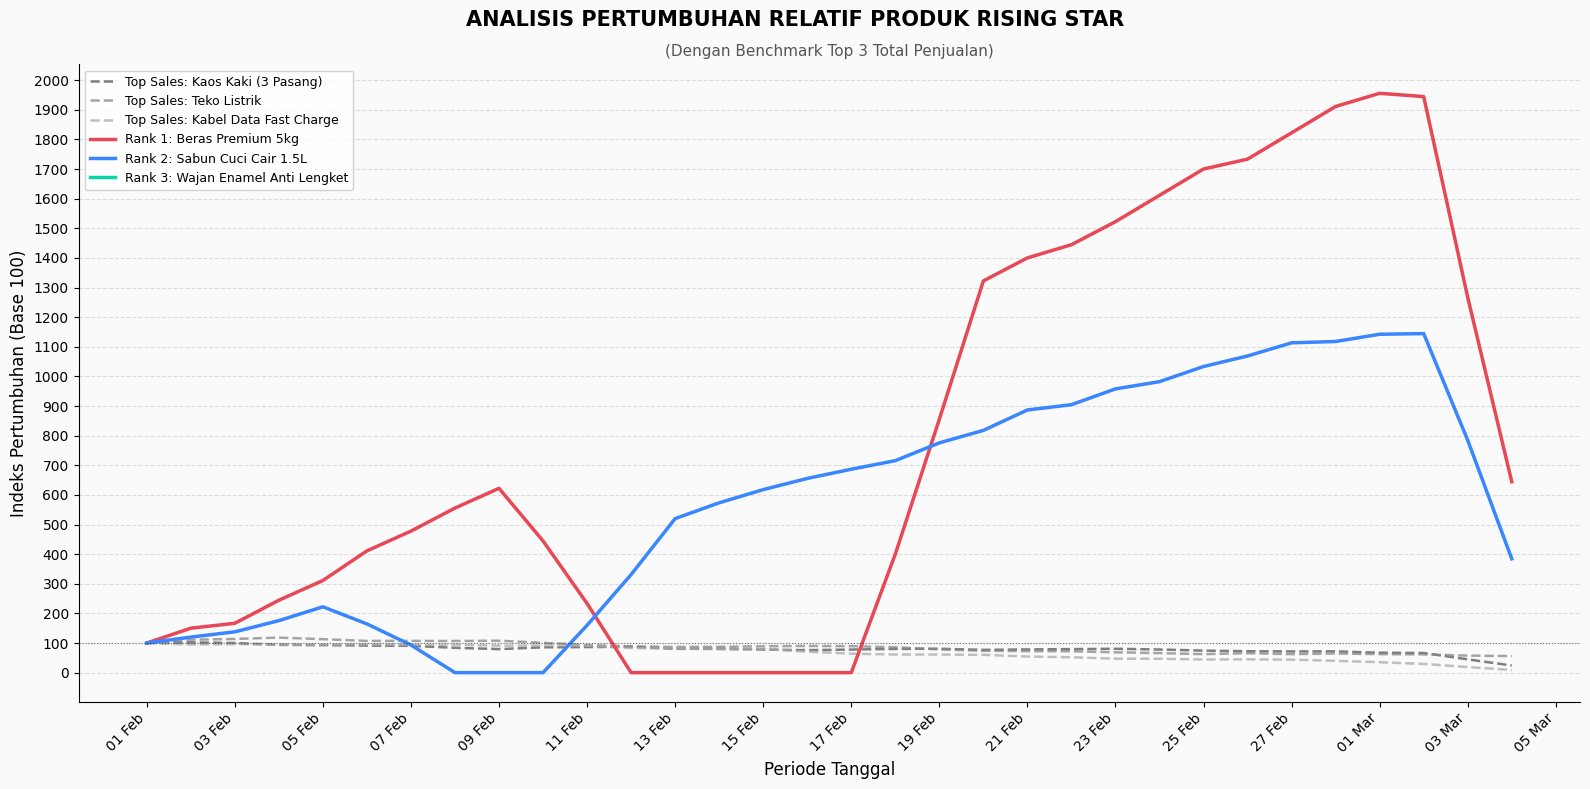

✅ Saved: rising_star_index.png


In [ ]:
# ── Chart 1: Relative Growth Index ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

dates = pivot_indexed.index

# Plot Top-3 benchmark (dashed)
for i, nama in enumerate(top3_nama):
    if nama in pivot_indexed.columns:
        ax.plot(
            dates, pivot_indexed[nama],
            color=TOP3_COLORS[i], linestyle='--', linewidth=1.8,
            alpha=0.75, label=f'Top Sales: {nama}'
        )

# Plot Rising Stars (solid)
for rank, nama in enumerate(rising_nama, start=1):
    if nama in pivot_indexed.columns:
        color = RISING_COLORS[(rank - 1) % len(RISING_COLORS)]
        ax.plot(
            dates, pivot_indexed[nama],
            color=color, linestyle='-', linewidth=2.5,
            label=f'Rank {rank}: {nama}'
        )

# Reference line at 100
ax.axhline(100, color='black', linewidth=0.8, linestyle=':', alpha=0.5)

# Axes labels & formatting
ax.set_ylabel('Indeks Pertumbuhan (Base 100)', fontsize=12)
ax.set_xlabel('Periode Tanggal', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# Title & subtitle
fig.suptitle(
    'ANALISIS PERTUMBUHAN RELATIF PRODUK RISING STAR',
    fontsize=15, fontweight='bold', y=0.98
)
ax.set_title(
    '(Dengan Benchmark Top 3 Total Penjualan)',
    fontsize=11, color='#555555', pad=6
)

# Legend
ax.legend(
    loc='upper left', fontsize=9,
    framealpha=0.85, edgecolor='#CCCCCC'
)

plt.tight_layout()
INDEX_PNG = 'rising_star_index.png'
fig.savefig(INDEX_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {INDEX_PNG}')

### 5b. Chart 2 — Actual MA Sales Values (`rising_star_actual.png`)

In [ ]:
# Content: Top-3 products + Top-1 Rising Star
top1_rising_nama = rising_nama[0]   # highest Growth %
actual_products  = list(dict.fromkeys([top1_rising_nama] + top3_nama))
pivot_actual     = get_ma_pivot(
    [k for k, n in kode_to_nama.items() if n in actual_products]
)

print('Products in actual chart:', actual_products)

Products in actual chart: ['Beras Premium 5kg', 'Kaos Kaki (3 Pasang)', 'Teko Listrik', 'Kabel Data Fast Charge']


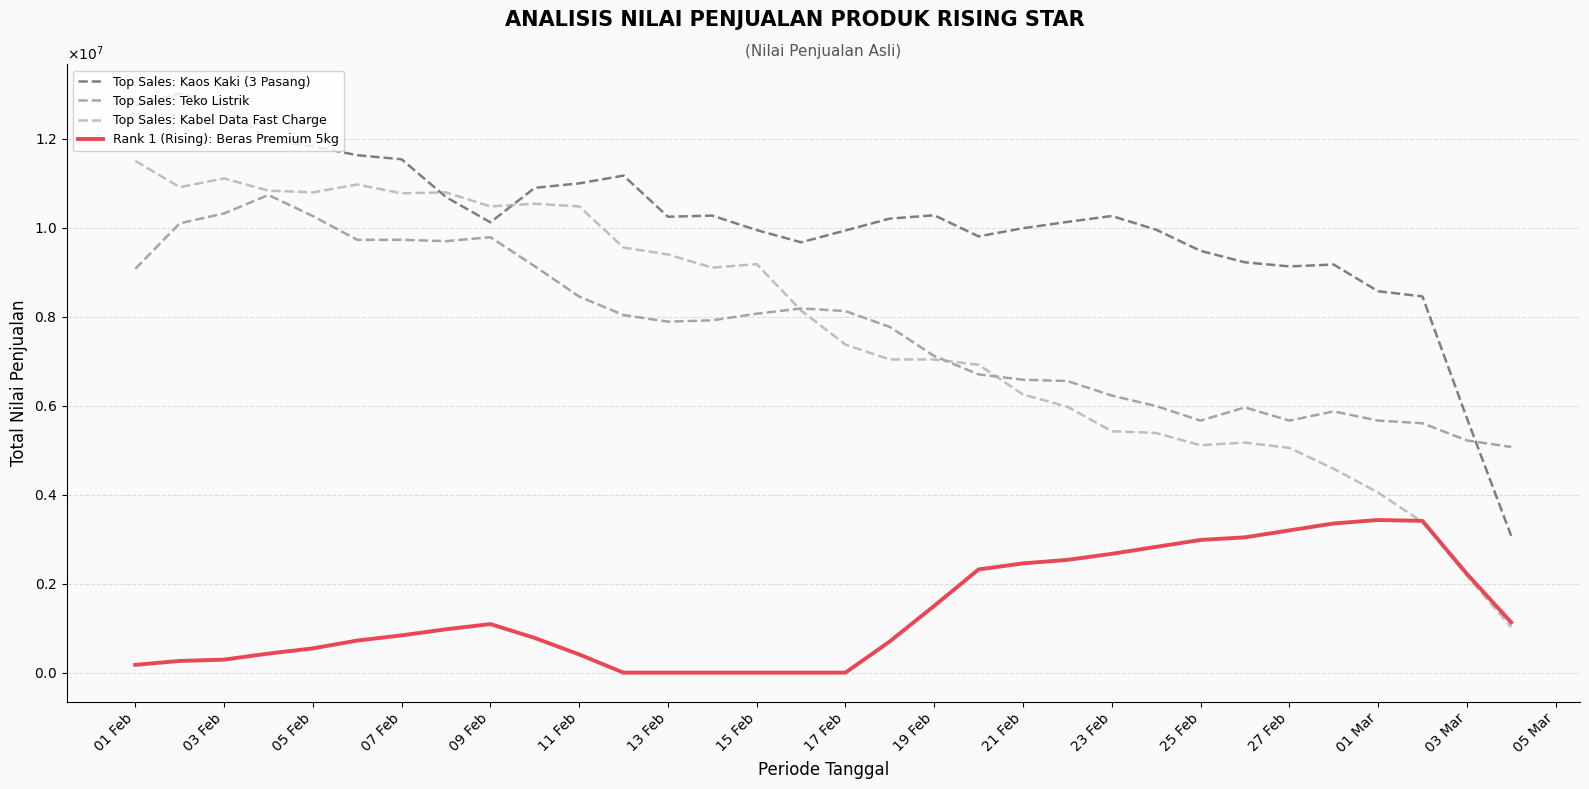

✅ Saved: rising_star_actual.png


In [ ]:
# ── Chart 2: Actual MA Values ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Plot Top-3 (dashed)
for i, nama in enumerate(top3_nama):
    if nama in pivot_actual.columns:
        ax.plot(
            pivot_actual.index, pivot_actual[nama],
            color=TOP3_COLORS[i], linestyle='--', linewidth=1.8,
            alpha=0.75, label=f'Top Sales: {nama}'
        )

# Plot Top-1 Rising Star (solid, highlighted)
if top1_rising_nama in pivot_actual.columns:
    ax.plot(
        pivot_actual.index, pivot_actual[top1_rising_nama],
        color=RISING_COLORS[0], linestyle='-', linewidth=2.8,
        label=f'Rank 1 (Rising): {top1_rising_nama}'
    )

# Axes
ax.set_ylabel('Total Nilai Penjualan', fontsize=12)
ax.set_xlabel('Periode Tanggal', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45, ha='right')

# Scientific notation on Y-axis
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(7, 7))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'ANALISIS NILAI PENJUALAN PRODUK RISING STAR',
    fontsize=15, fontweight='bold', y=0.98
)
ax.set_title(
    '(Nilai Penjualan Asli)',
    fontsize=11, color='#555555', pad=6
)

ax.legend(
    loc='upper left', fontsize=9,
    framealpha=0.85, edgecolor='#CCCCCC'
)

plt.tight_layout()
ACTUAL_PNG = 'rising_star_actual.png'
fig.savefig(ACTUAL_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {ACTUAL_PNG}')